In [88]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from helper.algorithms import ClassificationAlgorithms
# joblib for seving the model
import joblib

In [89]:

# Plot settings
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

In [90]:
df = pd.read_pickle("../processed_data/modelData.pkl")
df = df.drop("epoch (ms)", axis=1)

In [91]:
df_train = df.drop(["Participants", "Category", "Set"], axis=1)

X = df_train.drop("Label", axis=1)
y = df_train["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

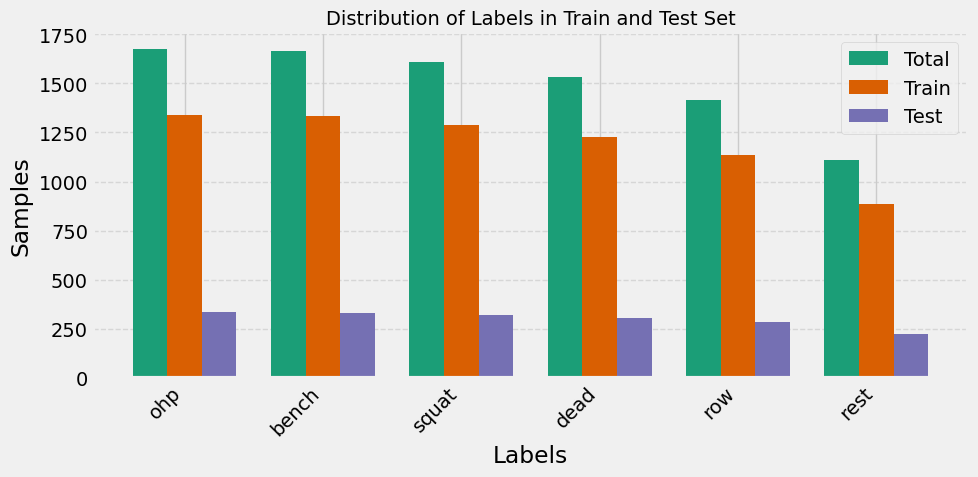

In [92]:
# Define the label order
labels = df_train["Label"].value_counts().index.tolist()

# Get counts, ensuring all labels are present
total_counts = df_train["Label"].value_counts().reindex(labels, fill_value=0)
train_counts = y_train.value_counts().reindex(labels, fill_value=0)
test_counts = y_test.value_counts().reindex(labels, fill_value=0)

# Bar width and positions
x = np.arange(len(labels))
width = 0.25

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot bars with manual offsets
ax.bar(x - width, total_counts, width=width, label='Total', color="#1b9e77")
ax.bar(x, train_counts, width=width, label='Train', color="#d95f02")
ax.bar(x + width, test_counts, width=width, label='Test', color="#7570b3")

# Improve appearance
ax.set_title("Distribution of Labels in Train and Test Set", fontsize=14)
ax.set_xlabel("Labels")
ax.set_ylabel("Samples")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [93]:
print("Train set:")
print(y_train.value_counts())
print("\nTest set:")
print(y_test.value_counts())
print("\nTotal set:")
print(df_train["Label"].value_counts())

Train set:
Label
ohp      1341
bench    1332
squat    1288
dead     1225
row      1133
rest      888
Name: count, dtype: int64

Test set:
Label
ohp      335
bench    333
squat    322
dead     306
row      284
rest     222
Name: count, dtype: int64

Total set:
Label
ohp      1676
bench    1665
squat    1610
dead     1531
row      1417
rest     1110
Name: count, dtype: int64


In [94]:
df.columns

Index(['Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z', 'Gyroscope_x',
       'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label', 'Category',
       'Set', 'pca_1', 'pca_2', 'pca_3', 'Accelerometer_r', 'Gyroscope_r',
       'Accelerometer_x_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5',
       'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_x_temp_mean_ws_5',
       'Gyroscope_y_temp_mean_ws_5', 'Gyroscope_z_temp_mean_ws_5',
       'Accelerometer_r_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5',
       'cluster_acc', 'cluster_gyro'],
      dtype='object')

In [95]:
# split the features 
basic_features = ["Accelerometer_x", "Accelerometer_y", "Accelerometer_z", "Gyroscope_x", "Gyroscope_y", "Gyroscope_z"]
squere_feactures = ["Accelerometer_r", "Gyroscope_r"]
pca_feactures = ["pca_1", "pca_2", "pca_3"]
cluster_feactures = ["cluster_acc", "cluster_gyro"]

print(f"Basic features: ", len(basic_features))
print(f"Squere features: ", len(squere_feactures))
print(f"PCA features: ", len(pca_feactures))
print(f"Cluster features: ", len(cluster_feactures))



Basic features:  6
Squere features:  2
PCA features:  3
Cluster features:  2


In [96]:
# creating the feature sets
feature_set_1 = list(set(basic_features))
feature_set_2 = list(set(feature_set_1 + squere_feactures))
feature_set_3 = list(set(feature_set_2 + pca_feactures))
feature_set_4 = list(set(feature_set_3 + cluster_feactures))
feature_set_5 = list(set(feature_set_4) - set(feature_set_1))

In [97]:
# preform forword selection using decision tree
X_train = X_train.select_dtypes(exclude=['datetime64[ns]'])

# select 10 best features
learner = ClassificationAlgorithms()

max_features = 10
selected_features, ordered_scores = learner.forward_selection(max_features, X_train, y_train)

Starting forward selection...
Selecting feature 1/10...
After selecting feature 1/10, selected features: ['pca_1']
Selecting feature 2/10...
After selecting feature 2/10, selected features: ['pca_1', 'Accelerometer_z']
Selecting feature 3/10...
After selecting feature 3/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x']
Selecting feature 4/10...
After selecting feature 4/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x', 'Gyroscope_r_temp_mean_ws_5']
Selecting feature 5/10...
After selecting feature 5/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x', 'Gyroscope_r_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5']
Selecting feature 6/10...
After selecting feature 6/10, selected features: ['pca_1', 'Accelerometer_z', 'Accelerometer_x', 'Gyroscope_r_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5', 'Gyroscope_r']
Selecting feature 7/10...
After selecting feature 7/10, selected features: ['pca_1', 'Accelerometer_z', 'Acceleromet

Text(0.5, 1.0, 'Forward selection')

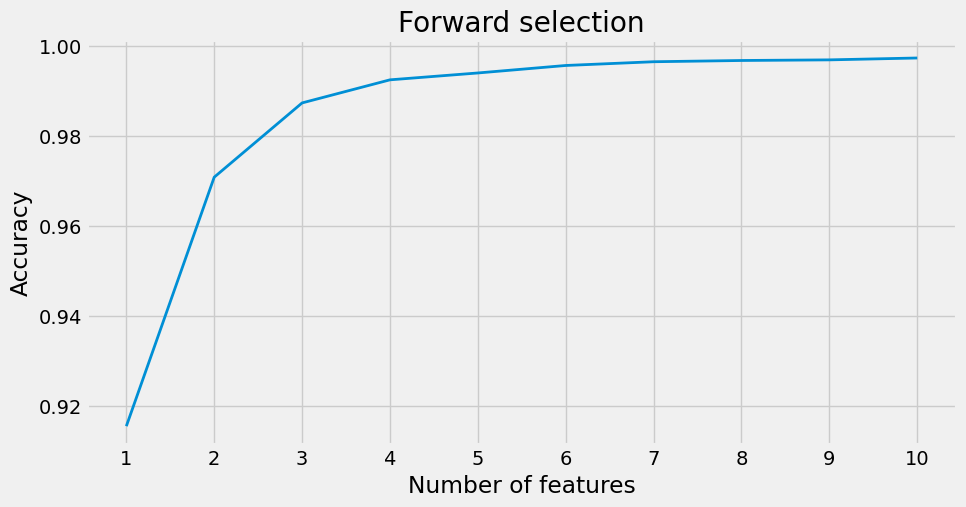

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, max_features + 1, 1), ordered_scores)
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, max_features + 1, 1))
plt.title("Forward selection")


In [99]:
# feature sets
possible_feature_sets = [feature_set_1, feature_set_2, feature_set_3, feature_set_4, feature_set_5, selected_features]
feature_names = ["Feature Set 1", "Feature Set 2", "Feature Set 3", "Feature Set 4", "Feature Set 5", "Selected features"]

iterations = 1
score_df = pd.DataFrame()

# iterate over feature sets
for i, f in enumerate(feature_names):
    print(feature_names[i])
    selected_train_X = X_train[possible_feature_sets[i]]
    selected_test_X = X_test[possible_feature_sets[i]]

    # Random Forest
    print("\tTraining random forest")
    performance_test_rf = sum(
        accuracy_score(y_test, learner.random_forest(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])
        for _ in range(iterations)
    ) / iterations

    # KNN
    print("\tTraining KNN")
    performance_test_knn = accuracy_score(y_test, learner.k_nearest_neighbor(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Decision Tree
    print("\tTraining decision tree")
    performance_test_dt = accuracy_score(y_test, learner.decision_tree(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])
    print(" " * 25, "Best parameters: ", learner.decision_tree(selected_train_X, y_train, selected_test_X, gridsearch=True)[2].get_params())

    # Naive Bayes
    print("\tTraining naive bayes")
    performance_test_nb = accuracy_score(y_test, learner.naive_bayes(selected_train_X, y_train, selected_test_X)[1])

    # SVM without kernel
    print("\tTraining SVM without kernel")
    performance_test_svm_no_kernel = accuracy_score(y_test, learner.svm_without_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # SVM with kernel
    #print("\tTraining SVM with kernel")
    #performance_test_svm_kernel = accuracy_score(y_test, learner.svm_with_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Logistic Regression
    print("\tTraining logistic regression")
    performance_test_logistic = accuracy_score(y_test, learner.logistic_regression(selected_train_X, y_train, selected_test_X)[1])

    # Save results to dataframe
    new_scores = pd.DataFrame({
        "model": ["RF", "KNN", "DT", "NB", "SVM-No-Kernel", "Logistic-Regression"], # can add SVM with kernel
        "feature_set": f,
        "accuracy": [performance_test_rf, performance_test_knn, performance_test_dt, performance_test_nb, performance_test_svm_no_kernel, performance_test_logistic], # performance_test_svm_kernel 
    })
    
    score_df = pd.concat([score_df, new_scores], ignore_index=True)


Feature Set 1
	Training random forest
                         Best parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
	Training KNN
                         Best parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}
	Training decision tree
                          Best parameters:  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_lea

In [100]:
score_df.sort_values(by="accuracy", ascending=False, inplace=True)
score_df

,model,feature_set,accuracy
30,RF,Selected features,0.981687
32,DT,Selected features,0.971698
12,RF,Feature Set 3,0.968368
18,RF,Feature Set 4,0.967814
6,RF,Feature Set 2,0.966149
0,RF,Feature Set 1,0.965039
2,DT,Feature Set 1,0.945061
14,DT,Feature Set 3,0.940622
8,DT,Feature Set 2,0.940067
20,DT,Feature Set 4,0.939512


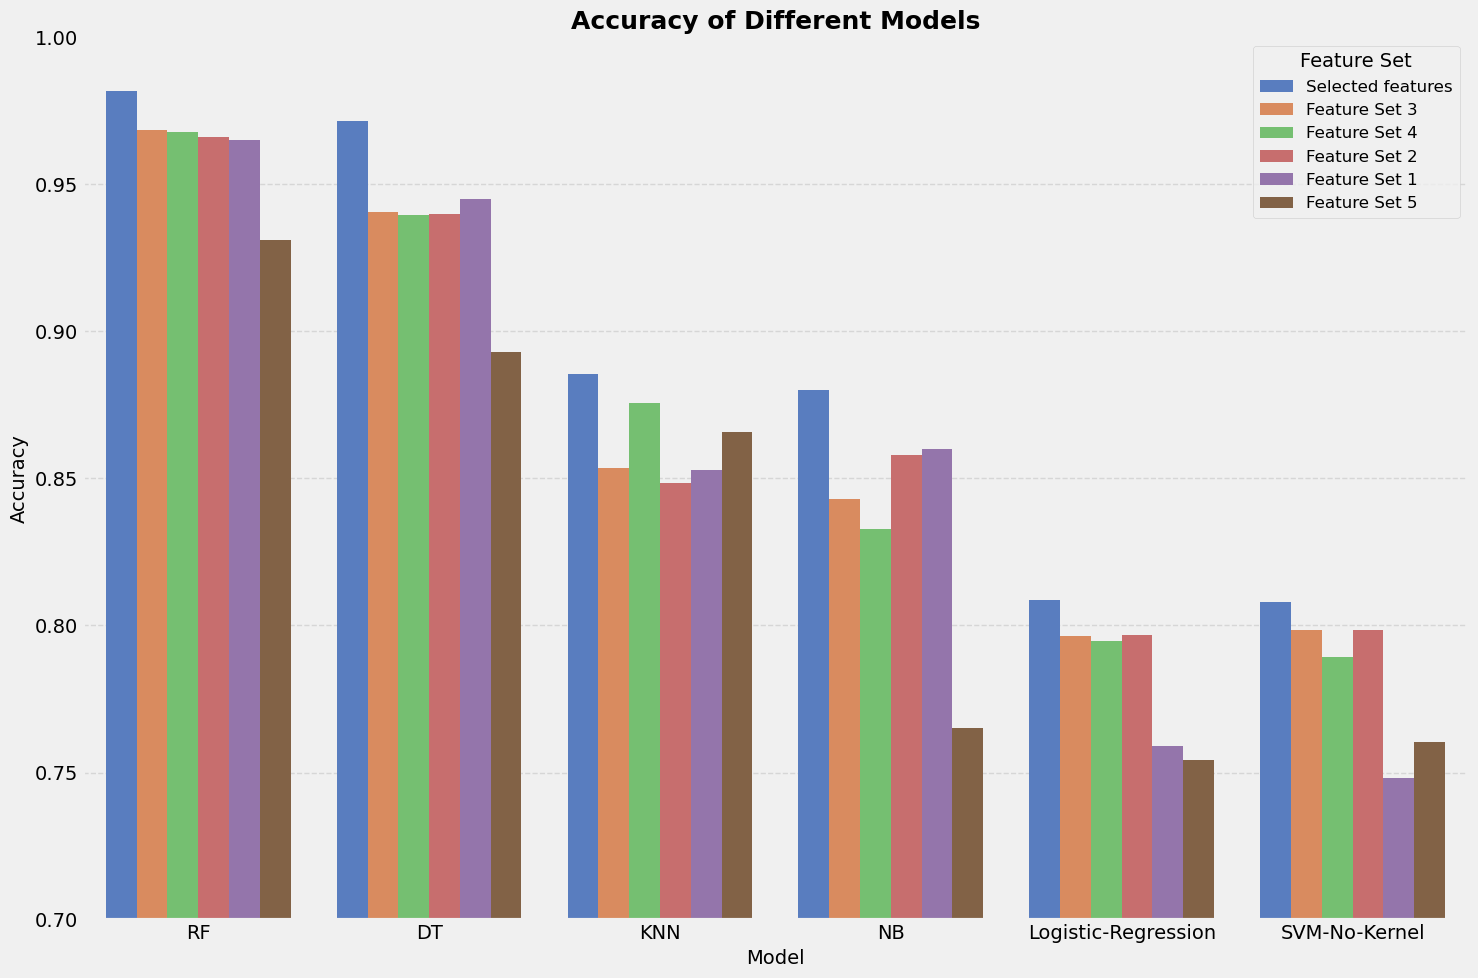

In [101]:
plt.figure(figsize=(15, 10))
sns.set_palette("pastel")  # pastel colors
sns.barplot(x="model", y="accuracy", hue="feature_set", data=score_df, palette="muted")
plt.title("Accuracy of Different Models", fontsize=18, fontweight="bold")
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.7, 1)
plt.legend(title="Feature Set", loc="upper right", fontsize=12) 
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### SVM-NO-Kernel

                         Best parameters: {'C': 100, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


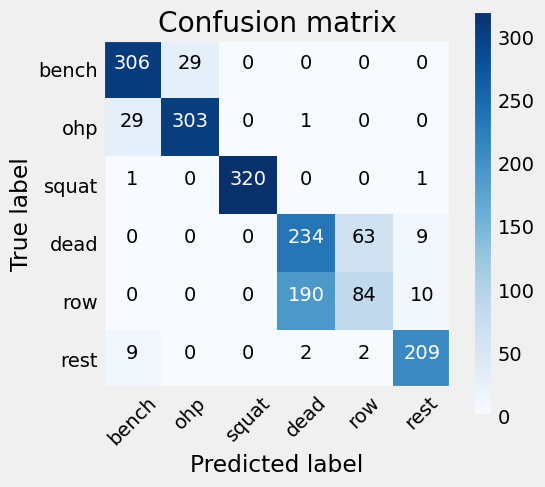

In [102]:
selected_train_X = X_train[selected_features]
selected_test_X = X_test[selected_features]

cm = confusion_matrix(y_test, learner.svm_without_kernel(selected_train_X, y_train, selected_test_X)[1], labels=labels)

# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()


### Logistic Regression

                         Best parameters: {'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


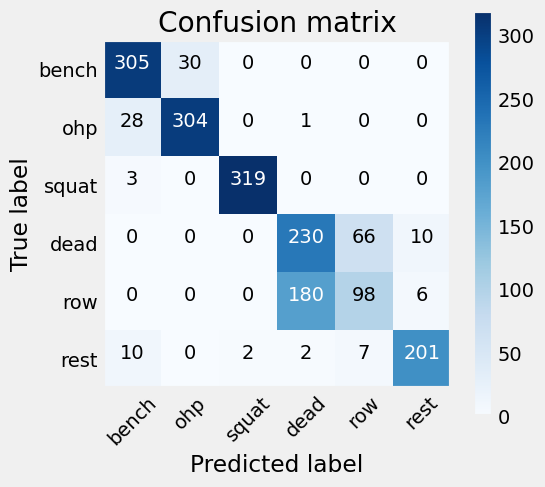

In [103]:
cm = confusion_matrix(y_test, learner.logistic_regression(selected_train_X, y_train, selected_test_X)[1], labels=labels)
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

### NB

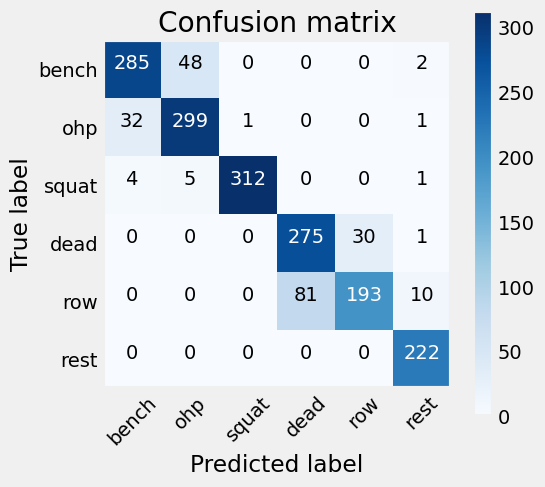

In [104]:
cm = confusion_matrix(y_test, learner.naive_bayes(selected_train_X, y_train, selected_test_X)[1], labels=labels)
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

### KNN

                         Best parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}


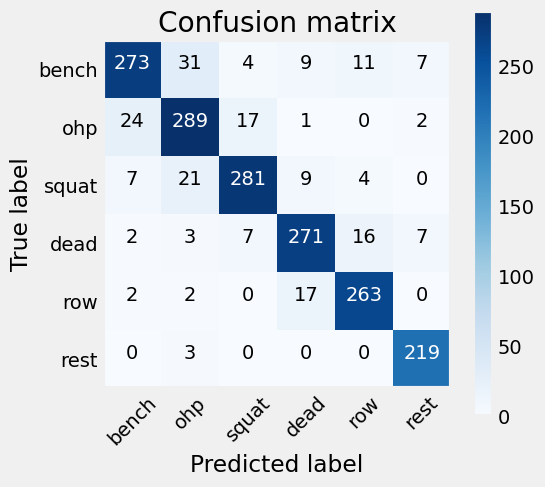

In [105]:
cm = confusion_matrix(y_test, learner.k_nearest_neighbor(selected_train_X, y_train, selected_test_X)[1], labels=labels)
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

### Decision Tree

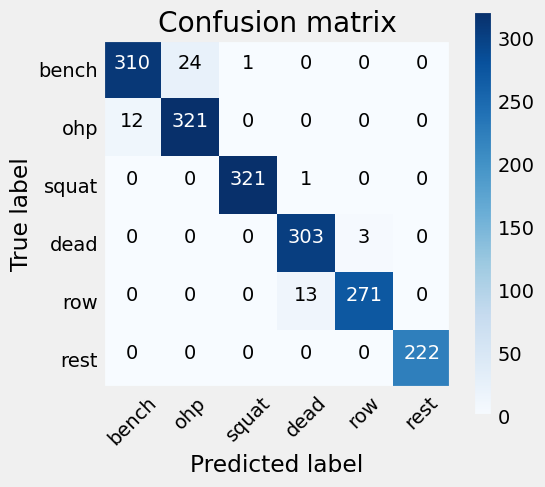

In [106]:
cm = confusion_matrix(y_test, learner.decision_tree(selected_train_X, y_train, selected_test_X)[1], labels=labels)
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

### Random Forest

In [107]:
# random forest
pred_train, pred_test, = learner.random_forest(X_train[selected_features], y_train, X_test[selected_features], gridsearch=True)

                         Best parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [108]:
# confusion matrix
cm = confusion_matrix(y_test, pred_test, labels=y.unique())
cm

array([[320,  13,   0,   0,   0,   0],
       [ 14, 320,   1,   0,   0,   0],
       [  0,   0, 322,   0,   0,   0],
       [  0,   0,   0, 304,   2,   0],
       [  0,   0,   0,   2, 282,   0],
       [  0,   0,   0,   0,   0, 222]])

In [109]:
# print accurrency on test set
accuracy_score(y_test, pred_test)

0.9822419533851277

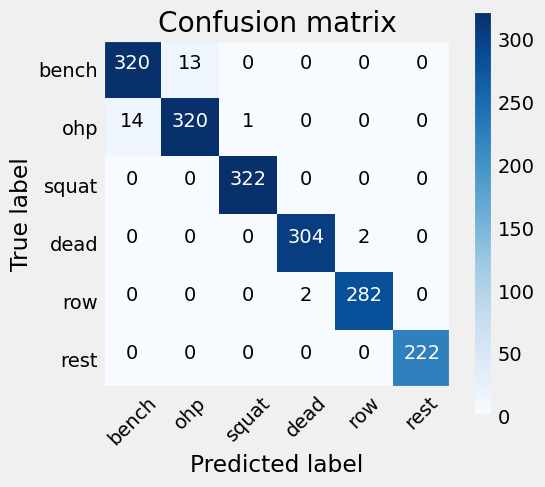

In [111]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

## Check overfitting

In [112]:
# trying the model for overfitting seeing how it proforms on the training set
cm = confusion_matrix(y_train, pred_train, labels=y.unique())
cm

array([[1330,    2,    0,    0,    0,    0],
       [   2, 1339,    0,    0,    0,    0],
       [   0,    0, 1288,    0,    0,    0],
       [   0,    0,    0, 1225,    0,    0],
       [   0,    0,    0,    0, 1133,    0],
       [   0,    0,    0,    0,    0,  888]])

In [113]:
# perint accuracy
accuracy_score(y_train, pred_train)

0.9994449840432913

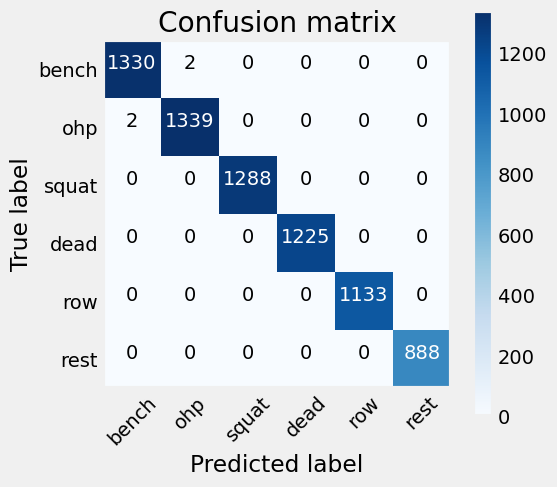

In [114]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

### No Overfitting

The model performs well on both training and test datasets, showing no signs of overfitting.

- **Training Accuracy**: High accuracy on the training set.
- **Test Accuracy**: Similar accuracy on the test set with minimal drop.
- **Consistent Metrics**: Precision, recall, and F1-scores are balanced across all classes.

This indicates the model generalizes well to new data.

### Models Comparsion

In [118]:
from sklearn.metrics import classification_report

# Define models and their predictions
model_names = ["RF", "KNN", "DT", "NB", "SVM-No-Kernel", "Logistic-Regression"]
model_predict_funcs = [
    learner.random_forest,
    learner.k_nearest_neighbor,
    learner.decision_tree,
    learner.naive_bayes,
    learner.svm_without_kernel,
    learner.logistic_regression
]

metrics_all = []

for name, func in zip(model_names, model_predict_funcs):
    if name == "NB":
        result = func(selected_train_X, y_train, selected_test_X)
    else:
        result = func(selected_train_X, y_train, selected_test_X, gridsearch=True)
    y_pred = result[1]
    report = classification_report(y_test, y_pred, labels=classes, output_dict=True)
    for cls in classes:
        metrics_all.append({
            "Model": name,
            "Class": cls,
            "F1-Score": report[cls]["f1-score"],
            "Precision": report[cls]["precision"],
            "Recall": report[cls]["recall"]
        })

metrics_df_all = pd.DataFrame(metrics_all)
metrics_df_all = metrics_df_all.sort_values(by=["Model", "F1-Score"], ascending=[True, False]).reset_index(drop=True)

                         Best parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
                         Best parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}
                         Best parameters: {'C': 100, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': None, 'tol': 0.0001, 'verbose': 0}
                         Best parameters: {'C': 10, 'class_weight': None, 'du

In [ ]:
# Pivot the table for better visualization
metrics_pivot = metrics_df_all.pivot_table(
    index='Model',
    columns='Class',
    values=['F1-Score', 'Precision', 'Recall']
)

# Reorder columns based on classes
metrics_pivot = metrics_pivot.reindex(classes, axis=1, level=1)

# Style the table
styled = (
    metrics_pivot.style
    .format("{:.3f}")
    .set_caption("Model Metrics by Exercise")
    .set_table_styles([
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '18px'), ('font-weight', 'bold')]},
        # Add vertical borders between metric groups
        {'selector': 'th.col_heading.level0', 'props': [('border-right', '2px solid #444')]},
        {'selector': 'td', 'props': [('border-right', '2px solid #444')]},
    ], overwrite=False)
    .set_properties(**{'text-align': 'center'})
)
styled


In [116]:
model = learner.random_forest(X_train[selected_features], y_train, X_test[selected_features], gridsearch=True)

                         Best parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [117]:
# save the model
#joblib.dump(model, '../model/random_forest_model.pkl')
